# Stochastic Numerics for Path-dependent Volterra Integral Equations : An interpolated $K$-integrated Euler scheme.

- This notebook is a complementary material of [GP2026](https://hal.science/hal-05585805), authored by [Emmanuel Gnabeyeu](https://emma-gnabeyeu.github.io/) and [Gilles Pagès](https://www.lpsm.paris/users/pages/index). It illustrates the numerical implementation of an interpolated K-integrated Euler scheme for path-dependent Stochastic Volterra integral equations.

- For further details, we refer the reader to [GP2026](https://hal.science/hal-05585805). The code is far from being optimized as it could be significantly improved through parallelisation. For any questions regarding the code or the paper, please feel free to reach out at emmanuel.gnabeyeu-mbiada@polytechnique.org.  I would be grateful for any feedback or suggestions to improve this notebook.

In [50]:
# Decorateur
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter
from scipy.special import gamma, gammainc
from scipy.stats import skew
from scipy.linalg import ldl
from scipy.linalg import cholesky
from scipy.integrate import quad
import scipy.integrate as integrate
from scipy.stats import norm
import scipy.special as sp
import scipy.sparse as sp_sparse
import time
from tqdm import tqdm

from scipy.optimize import minimize

from numpy.polynomial.legendre import leggauss


from numpy.random import default_rng, SeedSequence
import seaborn as sns
from scipy.optimize import fsolve, brentq

sns.set_theme()

sq = SeedSequence()
seed = sq.entropy       # on sauve la graine pour reproduire les résultats
print('seed = ', seed)
rng = default_rng(sq)
rng.standard_normal(5)

seed =  205788307615742528717534125413692032865


array([-0.73740397,  0.44993943,  0.09898844,  0.01561306, -1.74823237])

## Euler Maruyama Schemes for path-dependent SVIEs

In dimension 1, we focus on  the special case of a  scaled convolutive path-dependent stochastic Volterra equation associated to a convolutive kernel $K:\mathbb{R}_+\to \mathbb{R}_+$ 

\begin{equation}
X_t = X_0 +\int_0^t K_\alpha(t-s)b(s,X^s_\cdot)ds + \int_0^t K_\alpha(t-s)\sigma(s,X^{s}_\cdot)dW_s, \quad X_0\perp\!\!\!\perp W.
\end{equation}

where $K_{\alpha}(t) = \frac{u^{\alpha-1}}{\Gamma(\alpha)} \mathbb{1}_{\mathbb{R}_+}(t),  \quad \alpha>0.$
and the drift $b(t,x) $ and diffusion coefficient $\sigma(t,x) $ are Lipschitz continuous in $x\in C([0,T],\mathbb{R})$,  uniformly in $t\!\in [0,T]$. 

We consider path-dependent drift and diffusion coefficients of the form
		\begin{equation}
		b(t,x)= \mu_0-\lambda x(t) + \int_0^t x(t - u)\, \nu(du), \quad 	\sigma(t,x)
			=
			G\!\left(
			\int_0^t \Phi\big(x(u)\big)\,\mu(du)
			\right),
			\quad t \in [0,T], \ x \in \mathbb{X},
		\end{equation}
in the general delay case with $\mu_0, \lambda \in \mathbb{R}$ 
where $\mu, \nu \in \mathcal{M}$ and the function $G:\mathbb{R}\to\mathbb{R}$ is assumed to be bounded Lipschitz and
$\Phi:\mathbb{R}\to\mathbb{R}$ Lipschitz continuous so that, the mapping $x\mapsto \sigma(t,x)$ is globally Lipschitz on path space, and Lipschitz continuous in time.

Numerical Schemes:
$ \ [0,T]= \bigcup_{i=0}^{n-1} \ [t_i,t_{i+1}] $ The discrete time interpolated $K$-integrated Euler scheme $(\bar{X}_{t_k^n})_{0 \leq k \leq n}$ for the path-dependent Volterra Integral Equations equation above is given by:
		{\small
		\begin{align*}
			\bar X_{t_{k}^n} &= X_0 + \frac{1}{\Gamma(\alpha)}\sum_{\ell=1}^{k}b_{\ell-1}(t_{\ell-1}^n, \bar{X}_{t_0^n:t_{\ell-1}^n}) \int_{t^n_{\ell-1}}^{t_\ell^n} (t^n_k-s)^{\alpha-1}ds + \frac{1}{\Gamma(\alpha)}\sum_{\ell=1}^{k} \sigma_{\ell-1}(t_{\ell-1}^n, \bar{X}_{t_0^n:t_{\ell-1}^n})\int_{t^n_{\ell-1}}^{t^n_\ell} (t^n_k-s)^{\alpha-1}dW_s \\ &=
			  X_0 +\frac{\big(\frac{T}{n}\big)^{\alpha}}{\Gamma(\alpha+1)}\sum_{\ell=1}^{k} b_{\ell-1}(t_{\ell-1}^n, \bar{X}_{t_0^n:t_{\ell-1}^n}) \big[(k-l+1)^{\alpha}-(k-l)^{\alpha}\big] +\sum_{\ell=1}^{k}\sigma_{\ell-1}(t_{\ell-1}^n, \bar{X}_{t_0^n:t_{\ell-1}^n}) G^n_{k\ell}.
		\end{align*}
		}
		Here, $b_\ell$ and $\sigma_\ell$ are defined below, 
		$G^n$ is defined a Gaussian vector which can be efficiently simulated using
		Cholesky decomposition of the VCV matrix reading for every $ \ell=1,\ldots,n,$
		\begin{equation}
			\Sigma^{n,\ell} = \left[ \frac{T}{n}\int_0^{1} K_\alpha(\frac{T}{n}(i-u)) K_\alpha(\frac{T}{n}(j-u)) \, du \right]_{1 \leq i,j \leq n-\ell+1}=  \big(\tfrac Tn\big)^{2\alpha-1}\frac{1}{\Gamma(\alpha)^2}\big(\Sigma_{ij}\big)_{i,j=1:n-\ell+1}.
		\end{equation}
	where $\Sigma$ is defined by 
	\begin{equation}
	\Sigma_{ij} = \int_0^1 (i-1+v)^{\alpha-1}(j-1+v)^{\alpha-1}dv,\quad i\neq j\ge 1, \quad  \Sigma_{ii}= \frac{1}{2\alpha-1}\big(i^{2\alpha-1}-(i-1)^{2\alpha-1}\big), \, i\ge 1,
	\end{equation}

 we have
	$b_0(t_0^n, \bar{X}^h_{t_0^n:t_0^n}) = \mu_0-\lambda \bar{X}^h_{t^n_0}$, $\sigma_0(t_0^n, \bar{X}^h_{t_0^n:t_0^n}) = G(0)$ and for every $ \ell\geq1$, a trapezoidal rule yields the approximation:
		\begin{equation}
		%	b_\ell(t_\ell^n, \bar{X}^h_{t_0^n:t_\ell^n}) \approx -\lambda \bar{X}^h_{t^n_\ell} + \frac{h}{2}\left(\Phi(\bar{X}^h_{t_0^n}) + \Phi(\bar{X}^h_{t_\ell^n})\right) + h \mathbf{1}_{\ell \geq2}\sum_{m=1}^{\ell-1} \Phi(\bar{X}^h_{t_m^n}), \;
		\sigma_\ell(t_\ell^n, \bar{X}^h_{t_0^n:t_\ell^n}) \approx G\!\left(\frac{h}{2}\left(\Phi(\bar{X}^h_{t_0^n}) + \Phi(\bar{X}^h_{t_\ell^n})\right) + h \mathbf{1}_{\ell \geq2}\sum_{m=1}^{\ell-1} \Phi(\bar{X}^h_{t_m^n}) \right).
		\end{equation}

- We set numerical values of the parameters of the path-dependent Volterra equation:

We work in the following settings: $\mu \equiv \lambda_1$ is the Lebesgue measure on $(\mathbb{R}_+, {\cal B}or(\mathbb{R}_+))$
\begin{equation}
	\nu\equiv 0,\quad G(x) = \eta_1 \sqrt{c + \tanh(x)} \quad \text{and}\quad \Phi(x) = \eta_2 \sqrt{\kappa_2(x-a)^2 + \kappa_0}, \; \text{i.e.}\, \Phi^2\in \mathrm{Pol}_2(\mathbb{R})\subset \mathrm{Pol}(\mathbb{R})
\end{equation}
	Here, $\kappa_2,\kappa_0,\mu_0,\lambda,\eta_1, \eta_2>0$, $c>1$, and $a\in\mathbb{R}$ are fixed constants.
	In particular, the numerical values used for the simulation of the two settings are as follows:
	$\mu_0 = 2$, $\lambda = 0.2$, $\kappa_2 = 0.384$, $a = 0.095$, 
	$\kappa_0 = 0.0025$, $x_0 = 0$, $\eta_1=\eta_2 =c= 1$.


We set the number of time steps at $n= 1000$ and the horizon time at $T=1$. We performed a  Monte Carlo simulation of size $M=100\, 000$.

## Code and Implementation of the interpolated $K$-integrated

- We allow vectorized operations and take advantage of parallel computation and avoid looping over paths individually.

In [66]:
### Fractional Stochastic Volterra Integral Equations (FSVIE) wiht Affine drift: Asymptotic Stationarity and More.
class PathDependentStochasticVolterraSimulator:
    def __init__(self, config, random_state: np.random.Generator=rng):
        self.lambda_ = config['lambda_']  
        self.alpha = config['alpha']   # Fractional parameter
        self.mu_0 = config['mu_0']
        self.T = config['T'] # Time horizon
        self.n = config['n'] # Number of time steps
        self.M = config['M']  # Number of paths
        self.dt = config['T'] / config['n'] # Time step size
        self.x0 = config['x0']
        self.Phi1 = config['drift_x']
        self.Phi2 = config['sigma_x']

        #self.plt_ylimVarX = config['plt_ylimVarX']
        #self.plt_ylimSigma = config['plt_ylimSigma']
    
        self.times = np.linspace(0, config['T'], config['n'] + 1)  # Time discretization
        self.random_state = random_state  # Random number generator

        #if config['VCV'] is not None:
        #    self.T_expanded_2 = config['VCV']['T_expanded_2']  
        #    self.D_expanded_2 =  config['VCV']['D_expanded_2']
        #else:
        #    self.compute_covariance_matrix_expanded_2()
       
    def simulate_brownian_motion(self, increments=False)-> np.array:
        """Simulates Brownian motion paths or increments."""
        dB = np.sqrt(self.dt) * self.random_state.standard_normal((self.n, self.M))
        if increments:
            return dB
        else:
            brownian = np.zeros((self.n + 1, self.M))
            brownian[1:] = np.cumsum(dB, axis=0)
            return brownian

    def extended_cholesky_decomposition(self, A):
        """
        Perform an LDL^T decomposition of a symmetric matrix A.
        Returns L (lower triangular with unit diagonal) and D (diagonal).
        Assumes A is symmetric.
        """
        L, D, perm = ldl(A)
        # Apply a minimun threshold for every value
        threshold = 1e-10
        D = np.where(D < threshold, 0, D)
        # we just retain non-null parts (significant part) of both matrices
        n= np.count_nonzero(D)
        return L, np.sqrt(D)  # np.sqrt(D[:n,:n])  # Return L and the diagonal matrix D

    #%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    def simulate_compute_moments_plot_trajectories(self):
        """Simulates M trajectories and plots them."""
        X = self.simulate_path_cholesky_expanded_2()

        # Randomly select `n_trajectories` indices
        n_trajectories = 5
        indices = np.random.choice(self.M, n_trajectories, replace=False)

        # Plot values
        plt.figure(figsize=(6, 4))
        for m in indices:  # Iterate over the randomly selected indices
            plt.plot(self.times, X[:, m], label=f"Trajectory {m + 1}")

        # Configure plot
        plt.xlabel("Time")
        plt.ylabel(r"$\bar{X}_t$")
        plt.title(f"Simulation of {n_trajectories} Trajectories of the Process" + r"  $\bar{X}_t$,")
        # plt.legend()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'curves_trajectories_H0{int(np.round(100*(self.alpha-0.5),2))}_T{int(self.T)}.pdf')  
        # Display the figure
        plt.show()  

    def simulate_batches_compute_moments_plot_trajectories(self, total_batches=20):
        """Simulate M trajectories in batches and compute moments for each batch."""
        
        M = self.M
        num_trajectories_per_batch = self.M // total_batches
        self.M = num_trajectories_per_batch
        
        # Use tqdm to show the progress bar
        # for batch_num in tqdm(range(total_batches), desc="Processing batches", unit="batch", ncols=total_batches):
        for batch_num in range(total_batches):
            new_seed = self.random_state.integers(0, 2**32)
            # Create a new SeedSequence with the new seed and create a new RNG
            ### sq = SeedSequence(new_seed)
            ### self.random_state = default_rng(sq)
            print(f"Processing batch {batch_num+1}/{total_batches}...")
            # Simulate the trajectories for the current batch
            X, sigma_vals, increments = self.simulate_path_cholesky_expanded_2()

        # After all batches, aggregate the results
        
        # Randomly select `n_trajectories` indices
        n_trajectories = 500
        indices = np.random.choice(self.M, n_trajectories, replace=False)

        # Plot values
        plt.figure(figsize=(10, 6))
        for m in indices:  # Iterate over the randomly selected indices
            plt.plot(self.times, X[:, m], label=f"Trajectory {m + 1}")
        # put M to its initial value
        self.M = M
        # Configure plot
        plt.xlabel("Time")
        plt.ylabel(r"$\bar{X}_t$")
        plt.title(f"Simulation of {n_trajectories} Trajectories of the Process" + r"  $\bar{X}_t$,")
        # plt.legend()
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'curves_trajectories_H0{int(np.round(100*(self.alpha-0.5),2))}_T{int(self.T)}.pdf')  
        # Display the figure
        plt.show()  
    
    def build_lambda_fractional(self):
        """
        Build deterministic weight matrix Lambda^n for
        fractional kernel K_alpha(t) = t^{alpha-1} / Gamma(alpha)
        """
        n = self.n
        h = self.dt
        alpha = self.alpha
    
        Lambda_n = np.zeros((n, n))
        coef = h ** alpha / gamma(alpha + 1)
        for k in range(1, n + 1):
            for ell in range(1, k + 1):
                Lambda_n[k - 1, ell - 1] = coef * (
                    (k - ell + 1) ** alpha - (k - ell) ** alpha
                )
        return Lambda_n
   #%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    def compute_covariance_matrix_expanded_2(self):
        """Computes the expanded covariance matrix including cross-terms with Delta W."""
        print('computing VCV matrix')
        expanded_cov_matrix = np.zeros((self.n, self.n))
        # Set up the covariance for Delta W increments
    
        # terms Var(I^{n,l}_k)
        for k in tqdm(range(self.n)):
            integral = ((k+1)**(2*self.alpha-1)-k**(2*self.alpha-1)) /((2*self.alpha-1)*gamma(self.alpha)**2)
            expanded_cov_matrix[k, k] = integral  # Var(I^{n,l}_k) terms

        # Cross-covariance terms Cov(I^{n,l}_0, I^{n,l}_k') with IPP to remove singularity
        for k in tqdm(range(1, self.n)):
            integral, _ = quad(
                        lambda v: ((k + v)**(self.alpha-2))*(v**self.alpha),
                        0, 1
                    )
            expanded_cov_matrix[0, k] = ((k+1)**(self.alpha-1) - (self.alpha-1)*integral )/self.alpha
            expanded_cov_matrix[k, 0] = expanded_cov_matrix[1, k]
        # Cross-covariance terms Cov(I^{n,l}_k, I^{n,l}_k') and Var(I^{n,l}_k)
        for k in tqdm(range(self.n)): # for k in tqdm(range(1,self.n)):
            for k_prime in range(k+1, self.n): # Leverage symmetry and skip diagonal terms
                integral, _ = quad(
                        lambda v: ((k + v)*(k_prime + v))**(self.alpha-1),
                        0, 1
                    )
                    # Covariance terms between I^{n, l}_k and I^{n,l}_k'
                expanded_cov_matrix[k, k_prime] = expanded_cov_matrix[k_prime, k] = integral
        
        expanded_cov_matrix_2 = self.dt**(2*self.alpha-1) /(gamma(self.alpha)**2) * expanded_cov_matrix
        T_expanded_2, D_expanded_2 = self.extended_cholesky_decomposition(expanded_cov_matrix_2)
        self.T_expanded_2 =  T_expanded_2 
        self.D_expanded_2 =  D_expanded_2
        print('done')
        # return expanded_cov_matrix

    def simulate_path_cholesky_expanded_2(self): # , dW):
        """Simulates all M trajectories of the process X over the time horizon [0, T]."""
        print('Simulating trajectories')
        # Step 1: Compute covariance matrix and Cholesky decomposition
        self.compute_covariance_matrix_expanded_2()
        T_expanded, D_expanded = self.T_expanded_2, self.D_expanded_2
        nn_zero = np.count_nonzero(D_expanded) # or just n = len(D_expanded)

        # Initialize paths matrix, starting with x0
        X_paths = np.zeros((self.n + 1, self.M))
        X_paths[: , :] = self.x0  # self.random_state.normal(self.mu_0 / self.lambda_, np.sqrt(0.09), self.M)  
        
        # X_paths[:] = self.random_state.normal(self.mu_0 / self.lambda_, np.sqrt(0.09), self.M)
        # Precompute deterministic weight matrix Lambda^n
        Lambda_n = self.build_lambda_fractional()

        # Iteratively calculate the Gaussian vectors G^{n, \ell} and build X_paths
        for ell in tqdm(range(1, self.n+1)):

            Z = self.random_state.standard_normal(size=(self.n-ell+1, self.M)) # dW[:(self.n - ell + 2), :]

            T_ell = T_expanded[: self.n - ell + 1, :self.n - ell + 1]
            D_ell = D_expanded[:self.n - ell + 1, :self.n - ell + 1]

            G_n_ell = (T_ell @ D_ell) @  Z

            # Broadcast for vectorized computation (sum_terms: (k,), (M, 1) -> (k, M))
            b_ell_val = self.b_ell(ell - 1, X_paths[:ell,:]) 
            # b_val = np.array([ self.b_ell(l - 1, X_paths[:l,:]) for l in range(1, ell + 1) ]) 
            drift_vals = Lambda_n[ell-1: self.n+1, ell-1][:, np.newaxis] * b_ell_val[np.newaxis, :] # b_ell_val*Lambda_n[:,ell-1]

            sigma_ell_vals = self.sigma_ell(ell - 1, X_paths[:ell,:]) # self.sigma_x(X_paths[ell - 1, :])
            # compute vol
            sigma_term = sigma_ell_vals * G_n_ell # G_n_ell[:, :] 

            X_paths[ell: self.n + 1, :] += drift_vals + sigma_term
        print('done')
        return X_paths
        
    def build_lambda_fractional2(self, n):
        """
        Build deterministic weight matrix Lambda^n for
        fractional kernel K_alpha(t) = t^{alpha-1} / Gamma(alpha)
        """
        h = self.T/n
        alpha = self.alpha
    
        Lambda_n = np.zeros((n, n))
        coef = h ** alpha / gamma(alpha + 1)
    
        for k in range(1, n + 1):
            for ell in range(1, k + 1):
                Lambda_n[k - 1, ell - 1] = coef * (
                    (k - ell + 1) ** alpha - (k - ell) ** alpha
                )
        return Lambda_n
        
    def b_ell(self, ell, X_path):
        """
        Drift interpolator b_ell(t_ell, X_{0:ell})
        """
        if ell == 0:
            return self.mu_0-self.lambda_*X_path[ell]
        if ell == 1:
            return self.mu_0-self.lambda_*X_path[ell] + 0.5 * self.dt  * (self.Phi1(X_path[0]) + self.Phi1(X_path[ell]))
    
        term0 = 0.5 * self.dt  * (self.Phi1(X_path[0]) + self.Phi1(X_path[ell]))
        sum_term = self.dt  * np.sum([self.Phi1(X_path[m]) for m in range(1, ell)])
        return self.mu_0-self.lambda_*X_path[ell] + term0 + sum_term
    
    def sigma_ell(self, ell, X_path):
        """
        Diffusion interpolator sigma_ell(t_ell, X_{0:ell})
        """
        if ell == 0:
            return 0 # *X_path[ell]
        if ell == 1:
            return 0.5 * self.dt  * (self.Phi2(X_path[0]) + self.Phi2(X_path[ell]))
    
        term0 = 0.5 * self.dt  * (self.Phi2(X_path[0]) + self.Phi2(X_path[ell]))
        sum_term = self.dt  * np.sum([self.Phi2(X_path[m]) for m in range(1, ell)])
        return np.tanh(term0 + sum_term +1) # term0 + sum_term # self.Phi2(X_path[ell]) # 

    def simulate_path_cholesky_expanded_3(self): # , dW):
        """Simulates all M trajectories of the process X over the time horizon [0, T]."""
        print('Simulating trajectories')
        # Step 1: Compute covariance matrix and Cholesky decomposition
        self.n = 2*self.n
        self.compute_covariance_matrix_expanded_2()
        T_expanded, D_expanded = self.T_expanded_2, self.D_expanded_2
        nn_zero = np.count_nonzero(D_expanded) # or just n = len(D_expanded)
        self.n = self.n//2

        # Initialize paths matrix, starting with x0
        X_paths_2n = np.zeros((2*self.n + 1, self.M))
        X_paths_n = np.zeros((self.n + 1, self.M))
        X_paths_2n[: , :] = self.x0  # self.random_state.normal(self.mu_0 / self.lambda_, np.sqrt(0.09), self.M)  
        X_paths_n[: , :] = self.x0  
        # X_paths[:] = self.random_state.normal(self.mu_0 / self.lambda_, np.sqrt(0.09), self.M)
        # Precompute deterministic weight matrix Lambda^n
        Lambda_2n = self.build_lambda_fractional2(2*self.n)
        Lambda_n = self.build_lambda_fractional2(self.n)
        # Iteratively calculate the Gaussian vectors G^{n, \ell} and build X_paths
        G_2n_prev = None
        for ell in tqdm(range(1, 2*self.n+1)):
            Z_ell_fine = self.random_state.standard_normal(size=(2*self.n-ell+1, self.M)) # dW[:(self.n - ell + 2), :]
            T_ell = T_expanded[: 2*self.n - ell + 1, :2*self.n - ell + 1]
            D_ell = D_expanded[:2*self.n - ell + 1, :2*self.n - ell + 1]
            
            G_2n_ell = (T_ell @ D_ell) @ Z_ell_fine

            # Broadcast for vectorized computation (sum_terms: (k,), (M, 1) -> (k, M))
            # b_ell_val = self.b_ell(ell - 1, X_paths[:ell,:]) 
            # drift_vals = Lambda_n[ell-1: self.n+1, ell-1][:, np.newaxis] * b_ell_val[np.newaxis, :] # b_ell_val*Lambda_n[:,ell-1]

            # sigma_ell_vals = self.sigma_ell(ell - 1, X_paths[:ell,:]) # self.sigma_x(X_paths[ell - 1, :])
            # compute vol
            # sigma_term = sigma_ell_vals * G_n_ell # G_n_ell[:, :] 

            # X_paths[ell: self.n + 1, :] += drift_vals + sigma_term
            
            # ===== Schéma fin (2n) =====
            b_ell_2n = self.b_ell(ell - 1, X_paths_2n[:ell, :])
            drift_2n = Lambda_2n[ell-1:, ell-1][:, None] * b_ell_2n[None, :]
            sigma_2n = self.sigma_ell(ell - 1, X_paths_2n[:ell, :])
            sigma_term_2n = sigma_2n * G_2n_ell # G_2n_ell [:, :] 
            X_paths_2n[ell:, :] += drift_2n + sigma_term_2n
            
            if ell % 2 == 0:
                k = ell // 2
                G_2n_ell_aligned = np.vstack([np.zeros((1, self.M)), G_2n_ell]) # ensures same size
                # print(G_2n_ell_aligned)
                G_sum = G_2n_prev + G_2n_ell_aligned
                # G_sum = G_2n_ell + G_2n_prev   # somme deux à deux k = ell//2
                G_n_k = G_sum[1::2, :] # et non G_n_ell[::2, :] (car prends l'elts d'ind zero...
                b_ell_n = self.b_ell(k - 1, X_paths_n[:k, :])
                drift_n = Lambda_n[k-1:, k-1][:, None] * b_ell_n[None, :]
                sigma_n = self.sigma_ell(k - 1, X_paths_n[:k, :])
                X_paths_n[k:, :] += drift_n + sigma_n * G_n_k
            G_2n_prev = G_2n_ell  # à la fin de l'itération précédente
        print('done')
        return X_paths_2n, X_paths_n

    def calculate_convergence_error(self, n):
        """ Calculate the maximum error between simulations with grid sizes n and 2n. """
        # Update self.n for grid size n and simulate
        self.n = n
        X_2n, X_n = self.simulate_path_cholesky_expanded_3()  # Simulate for 2n grid size
        
        # Extract the even indices from X_2n (corresponding to t^n_k)
        X_2n_even = X_2n[::2, :]  # Take every second time step
        
        # Compute the maximum error between the two simulations
        max_error =  np.mean(np.sqrt(np.mean((X_n - X_2n_even)**2, axis=1))) # 
        # max_error = np.max(np.sqrt(np.mean((X_n - X_2n_even)**2, axis=1))) #
        # max_error = np.max(np.linalg.norm(X_n - X_2n_even, axis=1)/np.sqrt(self.M))  # Max error over all paths (M)

        # Compute the error at the final time T
        X_n_T = X_n[-1, :]  # Last time step for n grid size
        X_2n_T = X_2n[-1, :]  # Last time step for 2n grid size
        end_point_error = np.sqrt(np.mean((X_n_T - X_2n_T)**2)) # np.linalg.norm(X_n_T - X_2n_T)/np.sqrt(self.M))  # L2 norm of the error at T

        # return X_n, X_2n
        return max_error, end_point_error
        
    def plot_convergence_rate(self, H_values=[0.1, 0.4], max_N=512):
        """ Plot the convergence rate for different H values. """
        if len(H_values) == 1:
            fig, axes = plt.subplots(1, len(H_values), figsize=(6, 5))
            axes = [axes]
        else:
            fig, axes = plt.subplots(1, len(H_values), figsize=(10, 5))

        for i, H in enumerate(H_values):
            errors = []
            N_values = [int(2**k) for k in range(4, int(np.log2(max_N)) + 1)]
            # N_values = [200, 400, 600, 800]
            print(N_values)
            # Set the Hurst parameter alpha (H = alpha - 0.5)
            self.alpha = H + 0.5

            for n in N_values:
                # Calculate the maximum error for the given value of n
                max_error, _ = self.calculate_convergence_error(n)
                errors.append(max_error)

            logN = np.log(N_values)
            logerr = np.log(errors)
            pente, logC = np.polyfit(logN, logerr, 1)
            C = np.exp(logC)
            print('pente=',pente)
            # Plot the convergence rate
            axes[i].loglog(N_values, errors, label=f'H = {H}', marker='o')
            # axes[i].loglog(N_values, C*np.array(N_values)**(-1/2), 'r--', label=r'$n^{-1/2}$ (theory)')
            axes[i].loglog(N_values, C * np.array(N_values)**pente, 'r--',label=fr'fit: $n^{{{pente:.2f}}}$')
            
            # Fixer les ticks exactement sur tes N_values
            # axes[i].xaxis.set_major_locator(FixedLocator(N_values))
            # Afficher exactement les entiers
            # axes[i].xaxis.set_major_formatter(FixedFormatter([str(n) for n in N_values]))

            axes[i].set_title(f"Log-Log Convergence of the mean error for H = {H}")
            axes[i].set_xlabel('Number of steps (n)')
            axes[i].set_ylabel('Mean Error')
            axes[i].grid(True)
            axes[i].legend()

            # axes[i].loglog(N_values, errors, marker='o')
            
            # Désactive les ticks automatiques de l’axe x
            axes[i].xaxis.set_major_locator(FixedLocator(N_values))    # positions fixes
            axes[i].xaxis.set_major_formatter(FixedFormatter([str(n) for n in N_values]))  # labels exacts
            axes[i].xaxis.set_minor_locator(FixedLocator([]))          # supprime les ticks mineurs

        plt.tight_layout()
        # Save the figure
        plt.savefig(f'Log-Log_Convergence_MaxError_T{int(self.T)}.pdf')   
        # Display the figure
        plt.show()
        # return errors
    def plot_end_point_error(self, H_values=[0.1, 0.4], max_N=512):
        """ Plot the end-point error for different H values. """
        if len(H_values) == 1:
            fig, axes = plt.subplots(1, len(H_values), figsize=(6, 5))
            axes = [axes]
        else:
            fig, axes = plt.subplots(1, len(H_values), figsize=(10, 5))
        for i, H in enumerate(H_values):
            end_point_errors = []
            N_values = [2**k for k in range(4, int(np.log2(max_N)) + 1)]

            # Set the Hurst parameter alpha (H = alpha - 0.5)
            self.alpha = H + 0.5

            for n in N_values:
                # Calculate both errors for the given value of n
                _, end_point_error = self.calculate_convergence_error(n)
                end_point_errors.append(end_point_error)

            logN = np.log(N_values)
            logerr = np.log(end_point_errors)
            pente, logC = np.polyfit(logN, logerr, 1)
            C = np.exp(logC)
            print('pente=',pente)
            
            # Plot the end-point error
            axes[i].loglog(N_values, end_point_errors, label=f'End-point error for H = {H}', marker='s')
            # axes[i].loglog(N_values, end_point_errors[0]*np.array(N_values)**(-1/2), 'r--', label=r'$n^{-1/2}$ (theory)')
            axes[i].loglog(N_values, C * np.array(N_values)**pente, 'r--',label=fr'fit: $n^{{{pente:.2f}}}$')
            axes[i].set_title(f"Log-Log Convergence End Point error for H = {H}")
            axes[i].set_xlabel('Number of steps (n)')
            axes[i].set_ylabel('End Point Error')
            axes[i].grid(True)
            axes[i].legend()

            # Désactive les ticks automatiques de l’axe x
            axes[i].xaxis.set_major_locator(FixedLocator(N_values))    # positions fixes
            axes[i].xaxis.set_major_formatter(FixedFormatter([str(n) for n in N_values]))  # labels exacts
            axes[i].xaxis.set_minor_locator(FixedLocator([]))          # supprime les ticks mineurs
        plt.tight_layout()
        # Save the figure
        plt.savefig(f'Log-Log_Convergence_FinalError_T{int(self.T)}.pdf')  
        # Display the figure
        plt.show()

Simulating trajectories
computing VCV matrix


100%|████████████████████████████████████████| 400/400 [00:00<00:00, 478.17it/s]


done


100%|█████████████████████████████████████████| 400/400 [00:08<00:00, 45.71it/s]


done


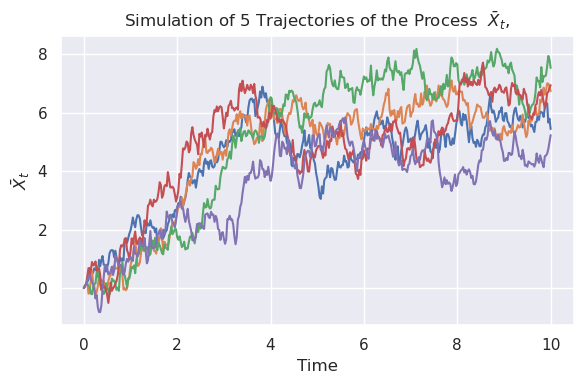

In [1222]:
# Instantiate and run the simulator
N = 400 # 400 # Number of steps
M= 2000 # 10000 # 0 # Simulation size
H = 0.4

lambda_= 0.2 # 1.2 # 0.2
mu_0 = 2
T= 10.0 # 10.0

kappa_0= 0.0025 # 0.25
kappa_1=0.00
kappa_2= 0.384 # 0.384

a = 0.095
b=1.2
drift_x = lambda x : 0 # np.sqrt(np.tanh(x)+3/2)/2 # np.sqrt(np.tanh(x)+1.2)/20000
sigma_x = lambda x :  np.sqrt(kappa_0 + kappa_2*(x-a)**2) # np.sqrt(np.tanh(x)+b)/20000 # np.sqrt(np.tanh(x)+1)/200 # 00 # np.sqrt(kappa_0 + kappa_2*x**2)
x_0 = 0.0 # 10.0
config = {
    'mu_0'   : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'drift_x' : drift_x,
    'sigma_x' : sigma_x,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'x0': x_0,
}  
Simulator = PathDependentStochasticVolterraSimulator(config)
Simulator.simulate_compute_moments_plot_trajectories()

Simulating trajectories
computing VCV matrix


100%|████████████████████████████████████████| 400/400 [00:00<00:00, 507.15it/s]


done


100%|█████████████████████████████████████████| 400/400 [00:08<00:00, 45.30it/s]


done


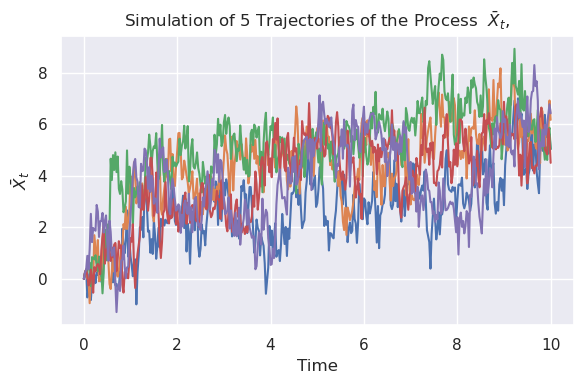

In [1246]:
# Instantiate and run the simulator
N = 400 # 400 # Number of steps
M= 2000 # 10000 # 0 # Simulation size
H = 0.1

lambda_= 0.2 # 1.2 # 0.2
mu_0 = 2
T= 10.0 # 10.0

kappa_0= 0.0025 # 0.25
kappa_1=0.00
kappa_2= 0.384 # 0.384

a = 0.095
b=1.2
drift_x = lambda x : 0 # np.sqrt(np.tanh(x)+3/2)/2 # np.sqrt(np.tanh(x)+1.2)/20000
sigma_x = lambda x :  np.sqrt(kappa_0 + kappa_2*(x-a)**2) # np.sqrt(np.tanh(x)+b)/20000 # np.sqrt(np.tanh(x)+1)/200 # 00 # np.sqrt(kappa_0 + kappa_2*x**2)
x_0 = 0.0 # 10.0
config = {
    'mu_0'   : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'drift_x' : drift_x,
    'sigma_x' : sigma_x,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'x0': x_0,
}  
Simulator = PathDependentStochasticVolterraSimulator(config)
Simulator.simulate_compute_moments_plot_trajectories()

## Strong convergence rate of the Mean error in log-log plot

In [1478]:
# Instantiate and run the simulator
N = 400 # 400 # Number of steps
M= 10000 # 0 # Simulation size
H = 0.1

lambda_= 0.2 # 1.2 # 0.2
mu_0 = 2
T= 10.0 

kappa_0= 0.0025 # 0.25
kappa_1=0.00
kappa_2= 0.384 # 0.384

a = 0.095
b=1.2
drift_x = lambda x : 0 # np.sqrt(np.tanh(x)+3/2)/2 # np.sqrt(np.tanh(x)+1.2)/20000
sigma_x = lambda x :  np.sqrt(kappa_0 + kappa_2*(x-a)**2) # np.sqrt(np.tanh(x)+b)/20000 # np.sqrt(np.tanh(x)+1)/200 # 00 # np.sqrt(kappa_0 + kappa_2*x**2)
x_0 = 0.0 # 10.0
config = {
    'mu_0'   : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'drift_x' : drift_x,
    'sigma_x' : sigma_x,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'x0': x_0,
}  
Simulator = PathDependentStochasticVolterraSimulator(config)

[16, 32, 64, 128, 256, 512]
Simulating trajectories
computing VCV matrix


100%|█████████████████████████████████████████| 32/32 [00:00<00:00, 3404.90it/s]


done


100%|██████████████████████████████████████████| 32/32 [00:00<00:00, 110.36it/s]


done
Simulating trajectories
computing VCV matrix


...

done
Simulating trajectories
computing VCV matrix


100%|██████████████████████████████████████| 1024/1024 [00:02<00:00, 372.79it/s]


done


100%|███████████████████████████████████████| 1024/1024 [07:09<00:00,  2.38it/s]


done
pente= -0.4161378238423923


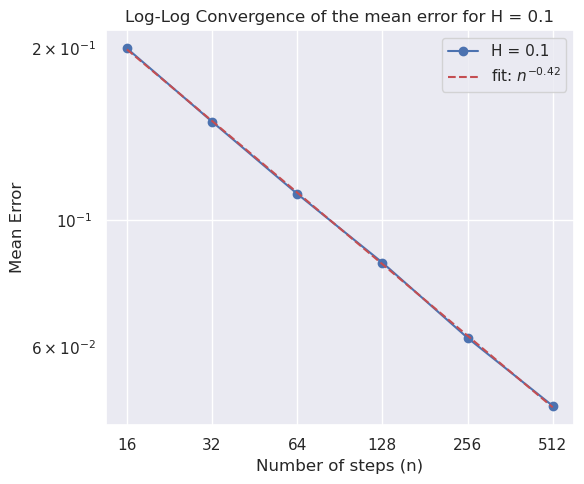

In [1480]:
# Plot convergence rates for different values of H
# Simulator = PathDependentStochasticVolterraSimulator(config)
Simulator.plot_convergence_rate(H_values=[0.1], max_N= 512)

In [1481]:
# Instantiate and run the simulator
N = 400 # 400 # Number of steps
M= 15000 # 0 # Simulation size
H = 0.4

lambda_= 1.2 # 0.2 # 1.2 # 0.2
mu_0 = 2
T= 9 

kappa_0= 0.0025 # 0.25
kappa_1=0.00
kappa_2= 0.384 # 0.384

a = 0.095
b=1.2
drift_x = lambda x : 0 # np.sqrt(np.tanh(x)+3/2)/2 # np.sqrt(np.tanh(x)+1.2)/20000
sigma_x = lambda x : np.sqrt(kappa_0 + kappa_2*(x-a)**2) # np.sqrt(np.tanh(x)+b)/20000 # np.sqrt(np.tanh(x)+1)/200 # 00 # np.sqrt(kappa_0 + kappa_2*x**2)
x_0 = 0.0 # 10.0
config = {
    'mu_0'   : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'drift_x' : drift_x,
    'sigma_x' : sigma_x,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'x0': x_0,
}  
Simulator = PathDependentStochasticVolterraSimulator(config)
# Simulator.simulate_compute_moments_plot_trajectories()

[16, 32, 64, 128, 256, 512]
Simulating trajectories
computing VCV matrix


100%|█████████████████████████████████████████| 32/32 [00:00<00:00, 4002.32it/s]


done


100%|███████████████████████████████████████████| 32/32 [00:00<00:00, 84.64it/s]


done
Simulating trajectories
computing VCV matrix


...

done
Simulating trajectories
computing VCV matrix


100%|██████████████████████████████████████| 1024/1024 [00:03<00:00, 316.13it/s]


done


100%|███████████████████████████████████████| 1024/1024 [11:02<00:00,  1.55it/s]


done
pente= -0.42918980252002065


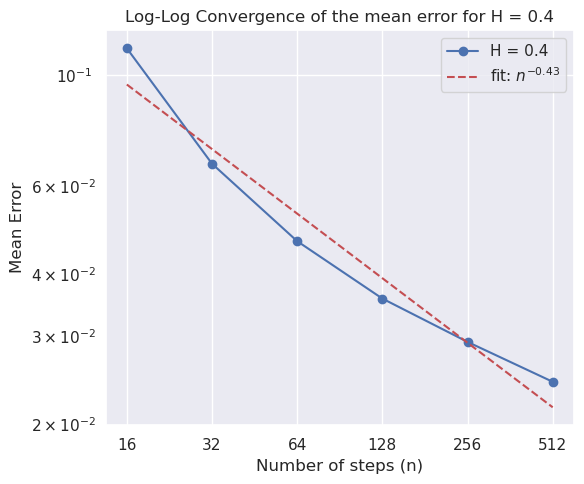

In [1482]:
# Plot convergence rates for different values of H
# Simulator = PathDependentStochasticVolterraSimulator(config)
Simulator.plot_convergence_rate(H_values=[0.4], max_N= 512)

## Strong convergence rate of the end point error in log-log plot

In [1324]:
# Instantiate and run the simulator
N = 400 # 400 # Number of steps
M= 10000 # 0 # Simulation size
H = 0.1

lambda_= 0.2 # 1.2 # 0.2
mu_0 = 2
T= 10.0

kappa_0= 0.0025 # 0.25
kappa_1=0.00
kappa_2= 0.384 # 0.384

a = 0.095
b=1.2
drift_x = lambda x : 0 # np.sqrt(np.tanh(x)+3/2)/2 # np.sqrt(np.tanh(x)+1.2)/20000
sigma_x = lambda x :  np.sqrt(kappa_0 + kappa_2*(x-a)**2) # np.sqrt(np.tanh(x)+b)/20000 # np.sqrt(np.tanh(x)+1)/200 # 00 # np.sqrt(kappa_0 + kappa_2*x**2)
x_0 = 0.0 # 10.0
config = {
    'mu_0'   : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'drift_x' : drift_x,
    'sigma_x' : sigma_x,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'x0': x_0,
}  
Simulator = PathDependentStochasticVolterraSimulator(config)

Simulating trajectories
computing VCV matrix


100%|█████████████████████████████████████████| 32/32 [00:00<00:00, 4624.21it/s]


done


100%|██████████████████████████████████████████| 32/32 [00:00<00:00, 118.47it/s]


done
Simulating trajectories
computing VCV matrix


...

done
Simulating trajectories
computing VCV matrix


100%|██████████████████████████████████████| 1024/1024 [00:03<00:00, 295.40it/s]


done


100%|███████████████████████████████████████| 1024/1024 [07:53<00:00,  2.16it/s]


done
pente= -0.49227323860408884


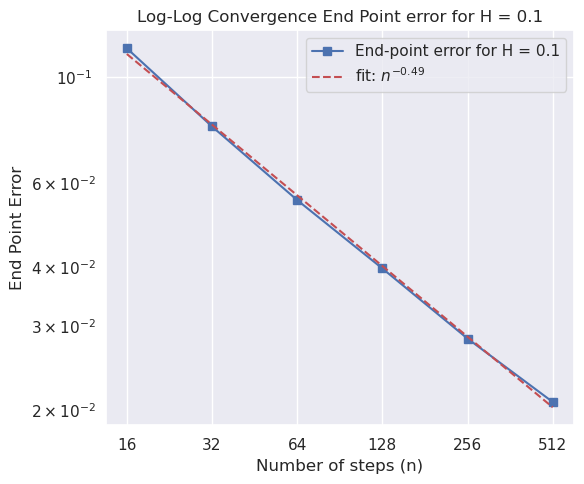

In [1296]:
# Plot the end-point error for different values of H
# Simulator = PathDependentStochasticVolterraSimulator(config)
Simulator.plot_end_point_error(H_values=[0.1], max_N= 512)

In [1398]:
# Instantiate and run the simulator
N = 400 # 400 # Number of steps
M= 10000 # 0 # Simulation size
H = 0.4

lambda_= 1.2 # 0.2 # 1.2 # 0.2
mu_0 = 2
T= 3.1

kappa_0= 0.0025 # 0.25
kappa_1=0.00
kappa_2= 0.384 # 0.384

a = 0.095
b=1.2
drift_x = lambda x : 0 # np.sqrt(np.tanh(x)+3/2)/2 # np.sqrt(np.tanh(x)+1.2)/20000
sigma_x = lambda x :  np.sqrt(kappa_0 + kappa_2*(x-a)**2) # np.sqrt(np.tanh(x)+b)/20000 # np.sqrt(np.tanh(x)+1)/200 # 00 # np.sqrt(kappa_0 + kappa_2*x**2)
x_0 = 0.0 # 10.0
config = {
    'mu_0'   : mu_0,
    'lambda_' :lambda_,
    'alpha' : H + 0.5,
    'drift_x' : drift_x,
    'sigma_x' : sigma_x,
    'T' : T ,# Time horizon
    'n' : N, # Number of time steps
    'M' : M, # Number of paths
    'x0': x_0,
}  
Simulator = PathDependentStochasticVolterraSimulator(config)
# Simulator.simulate_compute_moments_plot_trajectories()

Simulating trajectories
computing VCV matrix


100%|█████████████████████████████████████████| 32/32 [00:00<00:00, 3490.62it/s]


done


100%|██████████████████████████████████████████| 32/32 [00:00<00:00, 127.48it/s]


done
Simulating trajectories
computing VCV matrix


...

done
Simulating trajectories
computing VCV matrix


100%|██████████████████████████████████████| 1024/1024 [00:02<00:00, 371.66it/s]


done


100%|███████████████████████████████████████| 1024/1024 [05:01<00:00,  3.40it/s]


done
pente= -0.48319676511819726


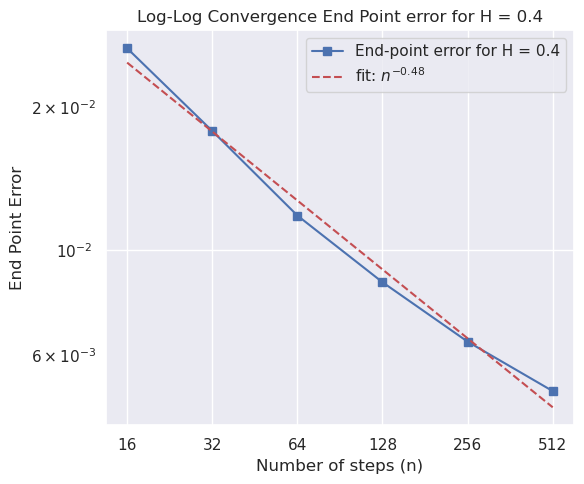

In [1400]:
# Plot the end-point error for different values of H
# Simulator = PathDepe;ndentStochasticVolterraSimulator(config)
Simulator.plot_end_point_error(H_values=[0.4], max_N= 512)

### Max error in log-log plot

[16, 32, 64, 128]
Simulating trajectories
computing VCV matrix


100%|█████████████████████████████████████████| 32/32 [00:00<00:00, 3059.09it/s]


done


100%|██████████████████████████████████████████| 32/32 [00:00<00:00, 399.92it/s]


done
Simulating trajectories
computing VCV matrix


...

done
Simulating trajectories
computing VCV matrix


100%|████████████████████████████████████████| 256/256 [00:00<00:00, 763.49it/s]


done


100%|█████████████████████████████████████████| 256/256 [00:04<00:00, 63.77it/s]


done
pente= 0.3093474265761121


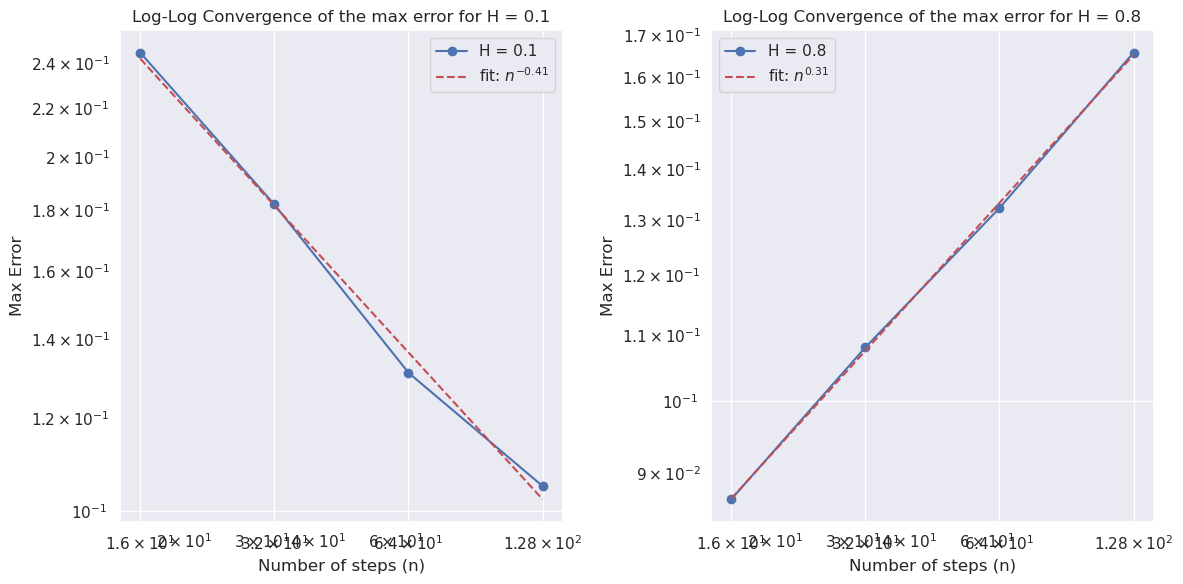

In [956]:
# Plot convergence rates for different values of H
Simulator = PathDependentStochasticVolterraSimulator(config)
Simulator.plot_convergence_rate(H_values=[0.1, 0.8], max_N= 252) # 512)

## References

[1] Emmanuel Gnabeyeu and Gilles Pagès. (2026) *On Path-dependent Volterra Integral Equations: Strong
Well-posedness and Stochastic Numerics.*

[2] Emmanuel Gnabeyeu and Gilles Pagès. (2025) *On a Stationarity Theory for Stochastic Volterra Integral
Equations.*